# Aplicação de um SIN para a valoração de apólice de seguro de vida.

O problema é determinar qual o preço a ser cobrado pela seguradora, frente a um determinado risco a ser identificado com a análise dos dados do cliente.
Nesse exemplo, o risco a ser avaliado será referente à **idade**, à **glicemia** e à **percentual de gordura corporal** do cliente.


In [1]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
from babel.numbers import format_currency as currency

## Modelagem do problema

A modelagem nebulosa do problema real compreende:

1.  definir o contexto e a questão a ser tratada. I.e., definir o problema que se quer resolver, a pergunta que se quer responder ou a decisão a ser tomada. Ainda, definir qual o contexto da questão, ou seja, definir os atores e sob quais circunstâncias, aspectos e negócio a questão está sendo percebida;

2.  definir qual a variável linguística de saída que será o resultado, resposta ou decisão da questão a ser tratada;

3.  definir os termos linguísticos (conjuntos nebulosos) da variável de saída. I.e., os possíveis valores que a variável de saída pode assumir;

4.  definir a representação dos conjuntos nebulosos da variável de saída. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

5.  definir as variáveis linguísticas de entrada;

6.  definir os termos linguísticos (conjuntos nebulosos) de cada variável de entrada. I.e., os possíveis valores que as variáveis de entrada podem assumir;

7.  definir a representação dos conjuntos nebulosos das variáveis de entrada. I.e., em geral, definir se a representação será por função de pertinência ou explícita (p. ex., listando os elementos do conjunto nebuloso em uma tabela);

8.  definir as regras de inferência;

9.  definir o método de inferência que, na maioria das vezes, poderá ser Mandani ou Larsen. Mas, podem ser usado outros métodos, dependendo do problema em questão;

10. definir o método de defuzzificação.


## Definição do problema


### Contexto

- **Objetivo:** Aplicação de um SIN para a valoração de apólice de seguro de vida.
- **Pergunta:** Qual é o preço a ser cobrado pela seguradora baseado em características do cliente?
- **Atores:** Representante da companhia seguradora (decisor), e cliente (sujeito do risco).
- **Circunstâncias:** O vendedor coletará dados do cliente e fará a simulação do custo.
- **Aspectos:** Espera-se que clientes com maior tendência a precisar de procedimentos médicos precisem pagar um custo mais alto pelos serviços. Não existe uma regra absoluta perfeitamente apropriada para decidir o preço, o que leva à indicação do uso de sistemas nebulosos.


### Saída

#### Preço

**Preço** mensal para contratação do seguro de saúde.

- Dado em reais (R$).
- Intervalo aproximado de R$ 400,00 a R$ 1400,00.
- Traduz o risco associado ao cliente.

Termos linguísticos:

- Baixo
  - Custo próximo a R$ 400,00.
- Alto
  - Custo próximo a R$ 1400,00.

Representação:

- Funções de pertinência lineares.
  - Crescente para o termo `Alto`, e decrescente para o termo `Baixo`.


/home/gabriel/dev/fuzzy_systems/.venv/lib64/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


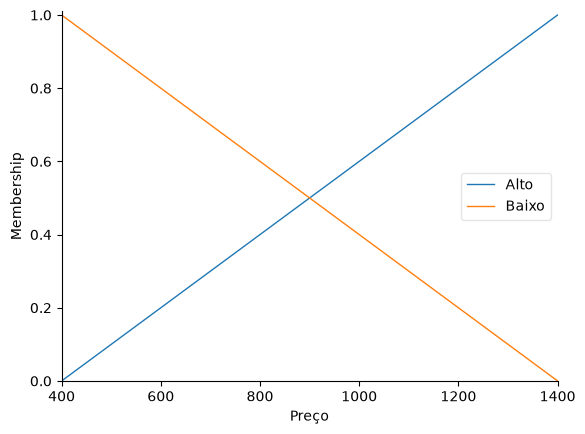

In [7]:
# Define o universo de valores.
price_universe = np.arange(400, 1401, 1)

# Define a variável.
price = ctrl.Consequent(price_universe, "Preço")

# Define a função de pertinência.
price["Alto"] = fuzzy.trimf(price.universe, [400, 1400, 1400])
price["Baixo"] = fuzzy.trimf(price.universe, [400, 400, 1400])

price.view()


### Entrada


#### Idade

**Idade** do cliente.

- Dado em anos.
- Intervalo aproximado de 1 a 100 anos.

Termos linguísticos:

- Jovem
  - Próximo a 10 anos.
- Adulto
  - Próximo a 40 anos.
- Idoso
  - Próximo a 70 anos.

Representação:

- Funções de pertinência lineares.
  - Decrescente para o termo `Jovem`, iniciando no início do intervalo.
  - Crescente para o termo `Idoso`, iniciando na metade do intervalo
- Função de pertinência triangular para o termo `Adulto`.
  - Crescente no início do intervalo, e passa a ser decrescente na metade.


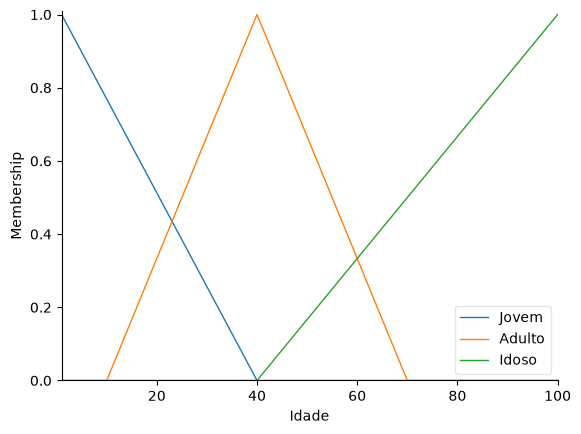

In [ ]:
# Define o universo de valores.
age_universe = np.arange(1, 101, 1)

# Define a variável.
age = ctrl.Antecedent(age_universe, "Idade")

# Define as funções de pertinência.

# Jovem: função linear decrescente.
age["Jovem"] = fuzzy.trimf(age_universe, [1, 1, 40])

# Adulto: função triangular.
age["Adulto"] = fuzzy.trimf(age_universe, [10, 40, 70])

# Idoso: função linear crescente.
age["Idoso"] = fuzzy.trimf(age_universe, [40, 100, 100])

age.view()


#### Glicemia

**Glicemia** no sangue do cliente.

- Dado em mg/dL.
- Intervalo aproximado de 40 a 200 mg/dL.

Termos linguísticos:

- Hipoglicemia: < 70 mg/dL
- Normal: 70 ≤ glicemia ≤ 99
- Pré-diabetes: 100 ≤ glicemia ≤ 126
- Diabetes: > 126

Representação:

- Funções de pertinência trapezoidais conforme os valores tabelados.


/home/gabriel/dev/fuzzy_systems/.venv/lib64/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


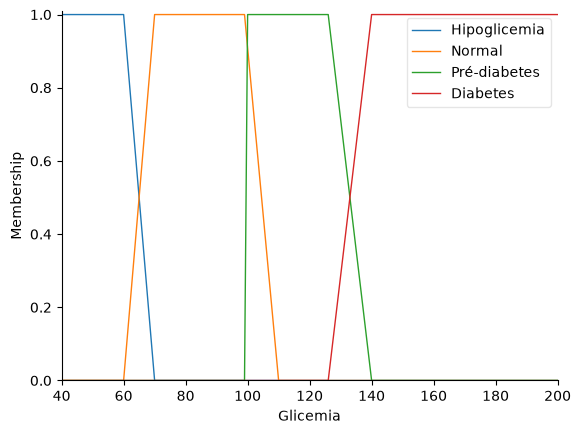

In [5]:
# Define o universo de valores.
glycemia_universe = np.arange(40, 201, 1)

# Define a variável.
glycemia = ctrl.Antecedent(glycemia_universe, "Glicemia")

# Define as funções de pertinência.
glycemia["Hipoglicemia"] = fuzzy.trapmf(glycemia_universe, [40, 40, 60, 70])
glycemia["Normal"] = fuzzy.trapmf(glycemia_universe, [60, 70, 99, 110])
glycemia["Pré-diabetes"] = fuzzy.trapmf(glycemia_universe, [99, 100, 126, 140])
glycemia["Diabetes"] = fuzzy.trapmf(glycemia_universe, [126, 140, 200, 200])

glycemia.view()

#### Percentual de gordura

Percentual de **gordura** no sangue do cliente.

- Dado em porcentagem.
- Intervalo de 5% a 45%.

Termos linguísticos:

- Baixo: de 5% a 15%.
- Médio: de 10% a 25%.
- Alto: de 20% a 45%.

Representação:

- Funções de pertinência trapezoidais conforme os valores tabelados.


/home/gabriel/dev/fuzzy_systems/.venv/lib64/python3.14/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


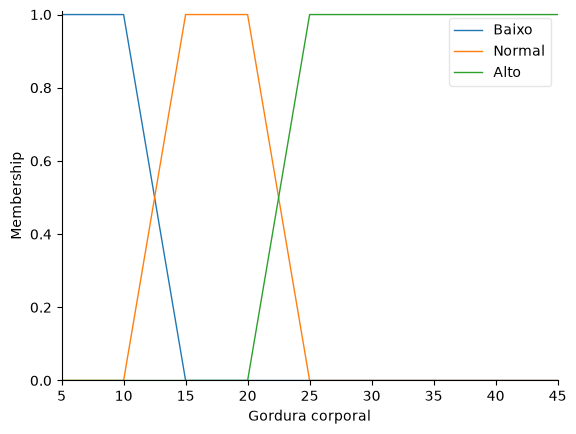

In [6]:
# Define o universo de valores.
body_fat_universe = np.arange(5, 46, 1)

# Define a variável.
body_fat = ctrl.Antecedent(body_fat_universe, "Gordura corporal")

# Define as funções de pertinência.
body_fat["Baixo"] = fuzzy.trapmf(body_fat_universe, [5, 5, 10, 15])
body_fat["Normal"] = fuzzy.trapmf(body_fat_universe, [10, 15, 20, 25])
body_fat["Alto"] = fuzzy.trapmf(body_fat_universe, [20, 25, 45, 45])

body_fat.view()